Column names: Index(['Task Number', 'Task Description', 'Start Date', 'End Date',
       '% Complete', 'Dependency'],
      dtype='object')
Timeline chart saved as 'timeline_chart_with_msproject_like_dependencies.png'.


PermissionError: [Errno 13] Permission denied: 'output_tasks_with_msproject_like_dependencies.xlsx'

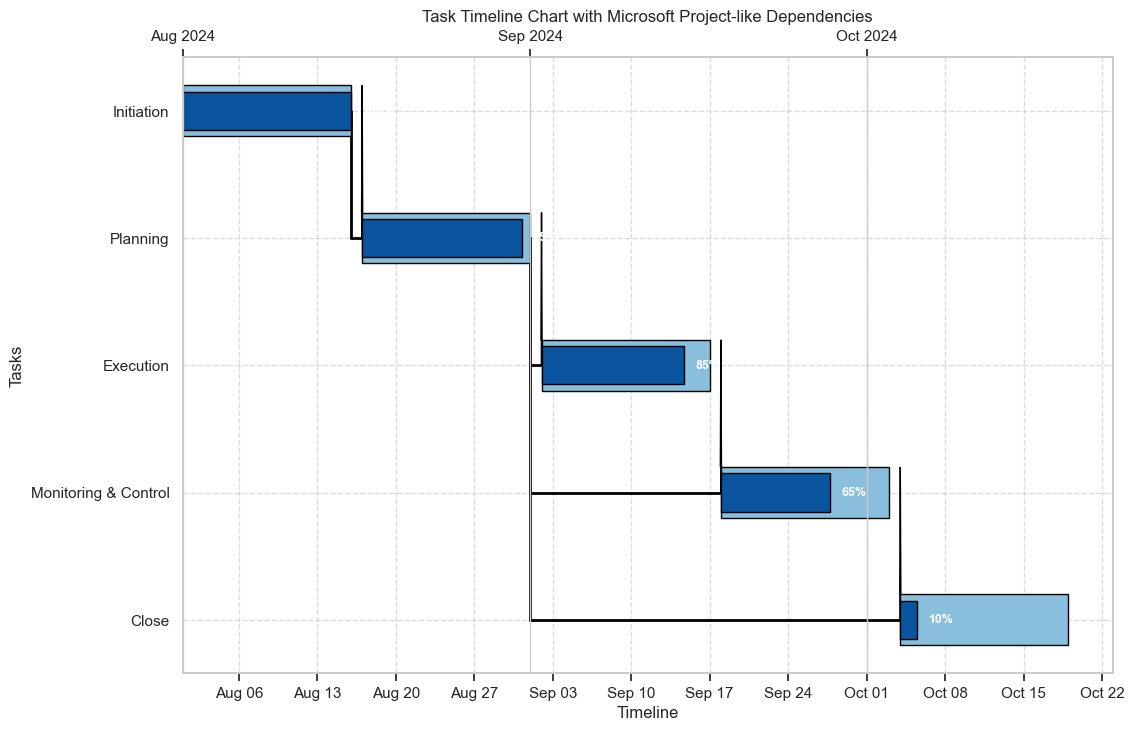

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
import seaborn as sns
from datetime import datetime
import xlsxwriter
import os

# Set the aesthetics for the chart using seaborn
sns.set(style="whitegrid")

# Read the input Excel file
input_file = 'input_tasks.xlsx'
if not os.path.exists(input_file):
    raise FileNotFoundError(f"The input file '{input_file}' was not found.")

df = pd.read_excel(input_file)

# Ensure the columns are stripped of any leading or trailing spaces
df.columns = df.columns.str.strip()

# Print column names to verify
print("Column names:", df.columns)

# Convert dates to datetime objects
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

# Create a figure and axis for the timeline chart
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate the position of each task on the y-axis
y_pos = range(len(df))

# Plot the bars for the timeline with rounded edges
for i, row in df.iterrows():
    full_length = (row['End Date'] - row['Start Date']).days
    completed_length = full_length * row['% Complete'] / 100
    
    # Full task duration bar
    ax.barh(i, full_length, left=row['Start Date'], color=sns.color_palette("Blues")[2], edgecolor='black', height=0.4, linewidth=1, zorder=2)
    
    # Completed portion of the task
    ax.barh(i, completed_length, left=row['Start Date'], color=sns.color_palette("Blues")[5], edgecolor='black', height=0.3, linewidth=1, zorder=3)
    
    # Annotate % Complete
    ax.text(row['Start Date'] + pd.Timedelta(days=completed_length) + pd.Timedelta(days=1), 
            i, f"{row['% Complete']}%", va='center', color='white', fontsize=9, weight='bold')

# Adding dependency lines with sharp, crisp lines similar to Microsoft Project
if 'Dependency' in df.columns:
    for i, row in df.iterrows():
        if pd.notna(row['Dependency']):
            # Find the index of the predecessor task using the 'Task Number' specified in 'Dependency'
            predecessor_idx = df[df['Task Number'] == row['Dependency']].index
            
            if not predecessor_idx.empty:
                predecessor_idx = predecessor_idx[0]
                # Coordinates for the line
                start_date_predecessor = df.iloc[predecessor_idx]['End Date']
                end_date_current = row['Start Date']

                # Vertical line from predecessor's end to current task's start
                ax.plot([start_date_predecessor, start_date_predecessor], 
                        [predecessor_idx, i], 
                        color='black', linewidth=2, zorder=1)

                # Horizontal line from predecessor's end to current task's start
                ax.plot([start_date_predecessor, end_date_current], 
                        [i, i], 
                        color='black', linewidth=2, zorder=1)

                # Adding an arrow to indicate direction
                ax.arrow(end_date_current, i, 0, -0.2, 
                         head_width=0.1, head_length=1, 
                         fc='black', ec='black', 
                         zorder=1)
            else:
                print(f"Dependency not found for Task Number: {row['Task Number']} -> Dependency: {row['Dependency']}")

# Format the x-axis to show both weeks and months
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Add a secondary x-axis for months at the top
ax_secondary = ax.twiny()
ax_secondary.xaxis.set_major_locator(mdates.MonthLocator())
ax_secondary.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_secondary.set_xlim(ax.get_xlim())
ax_secondary.xaxis.tick_top()

# Invert y-axis to have the first task on top
plt.gca().invert_yaxis()

# Set the y-axis labels for tasks
ax.set_yticks(y_pos)
ax.set_yticklabels(df['Task Description'])

# Add a grid for clarity
ax.grid(True, linestyle='--', alpha=0.7)

# Set axis labels
ax.set_xlabel('Timeline')
ax.set_ylabel('Tasks')

# Set the title of the chart
ax.set_title('Task Timeline Chart with Microsoft Project-like Dependencies')

# Save the figure as an image instead of showing it
timeline_image = 'timeline_chart_with_msproject_like_dependencies.png'
fig.savefig(timeline_image, dpi=300, bbox_inches='tight')
print(f"Timeline chart saved as '{timeline_image}'.")

# Write the DataFrame to a new Excel file and include the timeline chart
output_file = 'output_tasks_with_msproject_like_dependencies.xlsx'
with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    df.to_excel(writer, sheet_name='Tasks', index=False)
    
    # Add the timeline chart to the Excel file
    workbook = writer.book
    worksheet = writer.sheets['Tasks']
    worksheet.insert_image('H2', timeline_image)

print(f"Output file '{output_file}' created successfully.")
